# Sephora Data - Product EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Load dataset
product_data = pd.read_csv("../data/product_info.csv",encoding="iso-8859-1")

In [3]:
product_data.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320.0,3.6364,11,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827.0,4.1538,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253.0,4.2500,16,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018.0,4.4762,21,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691.0,3.2308,13,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [4]:
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   object 
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   float64
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   object 
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6895 non-null   object 
 10  variation_desc      1251 non-null   object 
 11  ingredients         7550 non-null   object 
 12  price_usd           8492 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      272 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

In [5]:
product_data.describe().T

,count,mean,std,min,25%,50%,75%,max
loves_count,8494.0,29177.976361,66092.661958,0.0,3756.500000,9876.50000,26841.250000,1401068.0
rating,8216.0,4.232340,3.467640,1.0,3.981725,4.28955,4.530725,315.0
price_usd,8492.0,51.646211,53.666909,3.0,25.000000,35.00000,58.000000,1900.0
value_price_usd,451.0,91.168537,79.195631,0.0,45.000000,67.00000,108.500000,617.0
sale_price_usd,272.0,20.059301,24.299052,0.0,8.000000,14.00000,25.000000,320.0
limited_edition,8494.0,0.070285,0.255642,0.0,0.000000,0.00000,0.000000,1.0
new,8494.0,0.071698,0.258002,0.0,0.000000,0.00000,0.000000,1.0
online_only,8494.0,0.219214,0.413738,0.0,0.000000,0.00000,0.000000,1.0
out_of_stock,8494.0,0.073581,0.261104,0.0,0.000000,0.00000,0.000000,1.0
child_count,8494.0,1.648575,5.513436,0.0,0.000000,0.00000,1.000000,105.0


In [6]:
# Unique values count for each column
unique_values_count = product_data.nunique()
print("Number of Unique Values for Each Column:")
print(unique_values_count)

Number of Unique Values for Each Column:
product_id            8494
product_name          8415
brand_id               305
brand_name             305
loves_count           7436
rating                4394
reviews               1557
size                  2056
variation_type           8
variation_value       2729
variation_desc         936
ingredients           6540
price_usd              298
value_price_usd        174
sale_price_usd          89
limited_edition          2
new                      2
online_only              2
out_of_stock             2
sephora_exclusive        3
highlights            4418
primary_category        11
secondary_category      43
tertiary_category      119
child_count             55
child_max_price        222
child_min_price        208
dtype: int64


In [7]:
missing_values = product_data.isnull().sum()
print("\nMissing Values:\n")
print(missing_values[missing_values > 0])


Missing Values:

rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1599
variation_desc        7243
ingredients            944
price_usd                2
value_price_usd       8043
sale_price_usd        8222
sephora_exclusive        1
highlights            2206
secondary_category       8
tertiary_category      990
child_max_price       5740
child_min_price       5742
dtype: int64


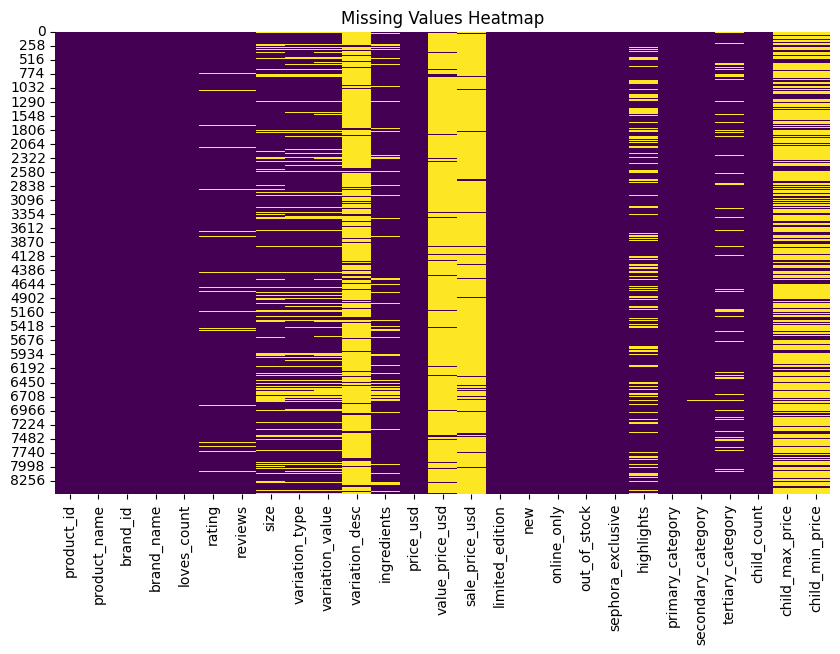

In [11]:
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(product_data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [12]:
# Check for duplicate rows
duplicates = product_data.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicates)


Number of Duplicate Rows: 0


In [14]:
# Categorical and numerical column separation
categorical_cols = product_data.select_dtypes(include=['object']).columns
numerical_cols = product_data.select_dtypes(include=['number']).columns
print("Categorical Columns:", categorical_cols.tolist())
print("Numerical Columns:", numerical_cols.tolist())

Categorical Columns: ['product_id', 'product_name', 'brand_id', 'brand_name', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category']
Numerical Columns: ['loves_count', 'rating', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'child_count', 'child_max_price', 'child_min_price']


In [18]:
# check how many categories in each categorical_cols:
for cols in categorical_cols:
    print(f"{cols} has {product_data[cols].nunique()} unique values")

product_id has 8494 unique values
product_name has 8415 unique values
brand_id has 305 unique values
brand_name has 305 unique values
reviews has 1557 unique values
size has 2056 unique values
variation_type has 8 unique values
variation_value has 2729 unique values
variation_desc has 936 unique values
ingredients has 6540 unique values
sephora_exclusive has 3 unique values
highlights has 4418 unique values
primary_category has 11 unique values
secondary_category has 43 unique values
tertiary_category has 119 unique values


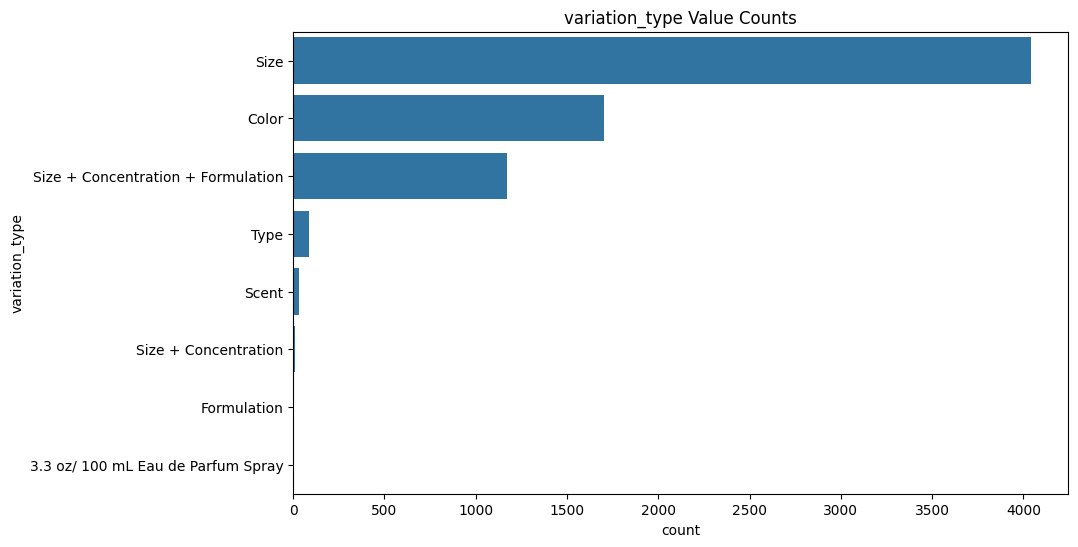

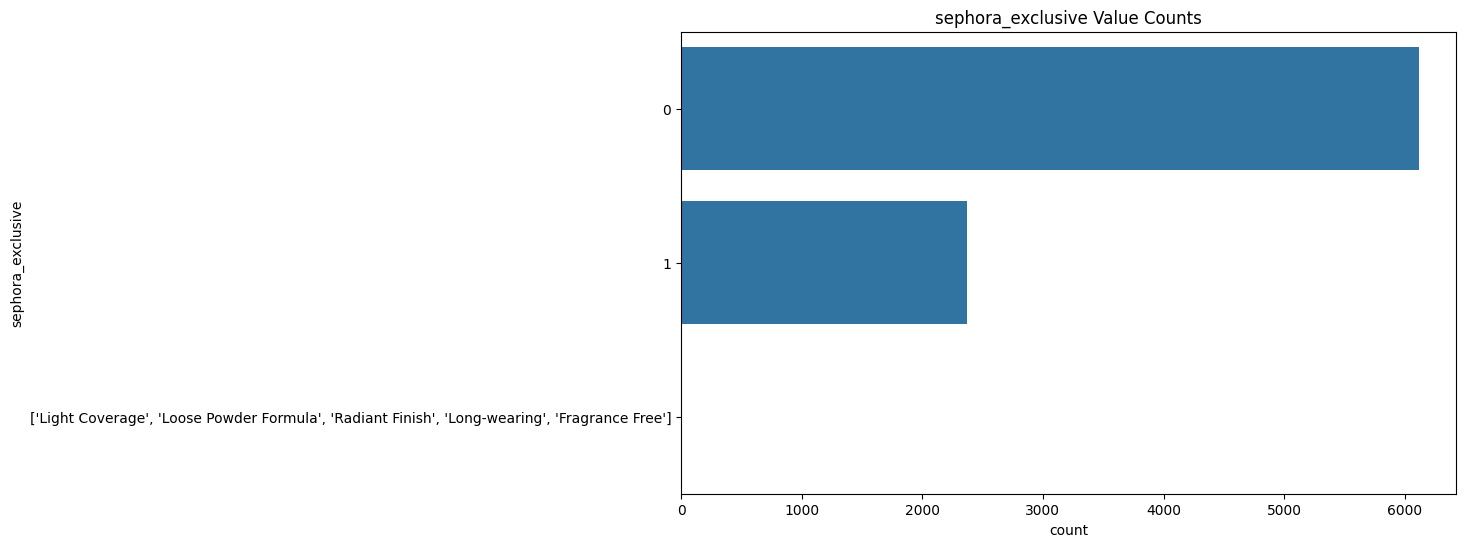

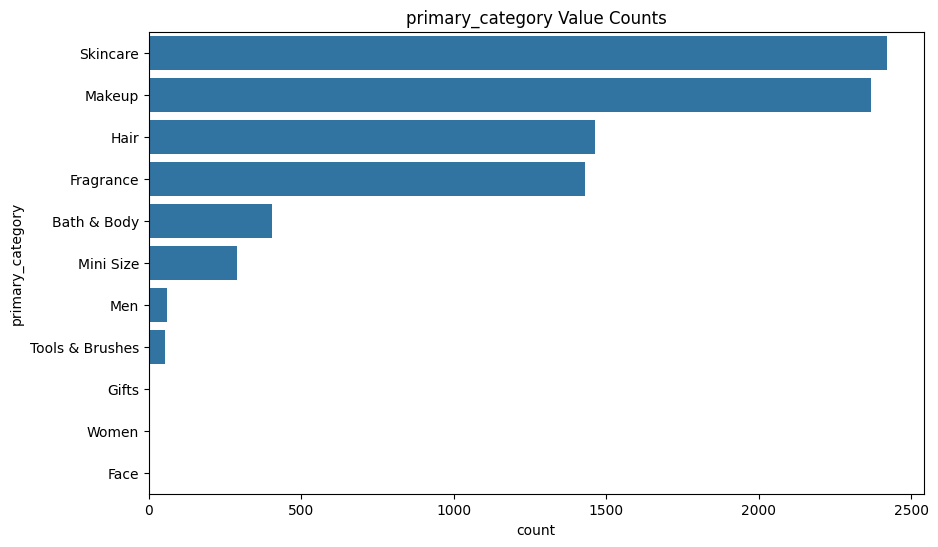

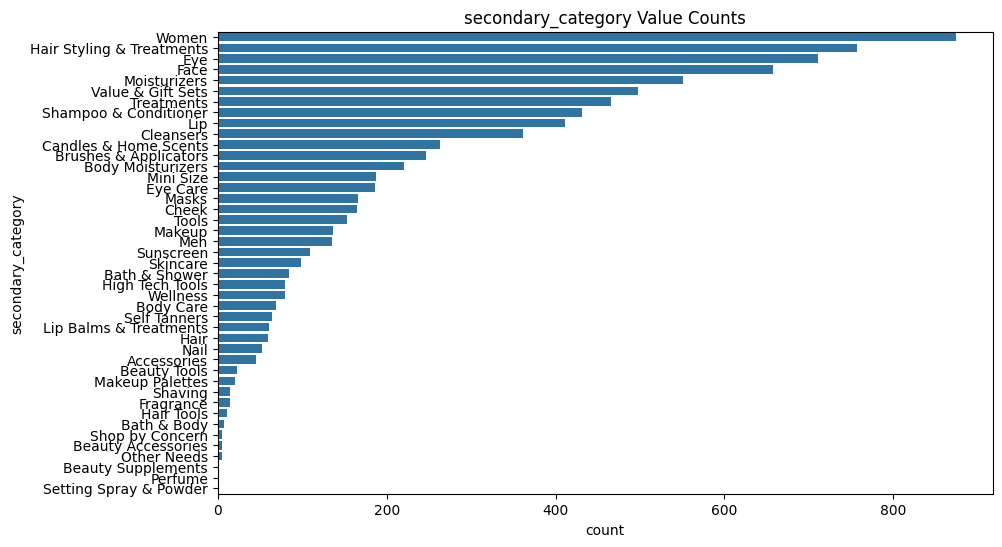

In [21]:
# If there are more than 50 categories in a column, we will not plot the countplot
for cols in categorical_cols:
    if product_data[cols].nunique() < 50:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=cols, data=product_data, order=product_data[cols].value_counts().index)
        plt.title(f"{cols} Value Counts")
        plt.show()

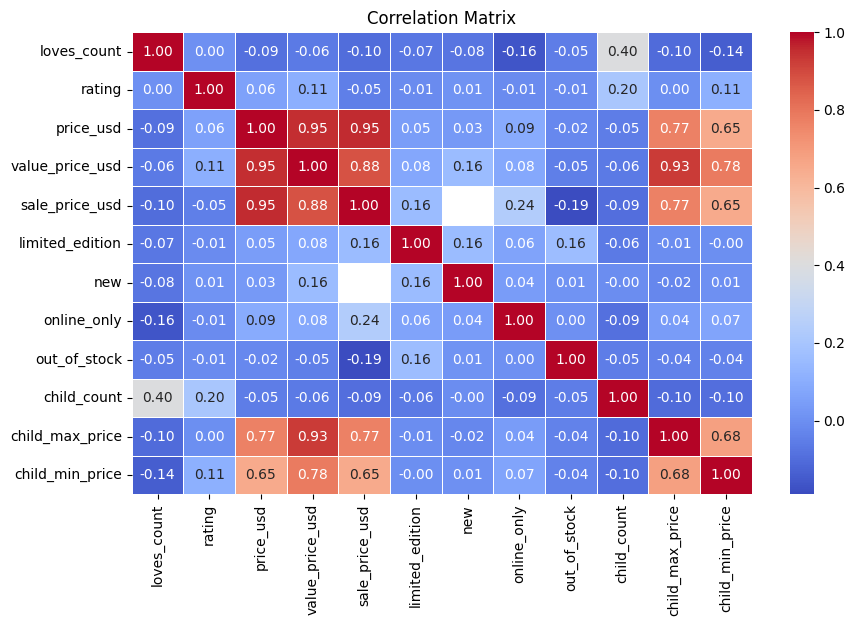

In [71]:
# Correlation matrix for numerical columns
plt.figure(figsize=(10, 6))
corr_matrix = product_data[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


Number of Products per Brand:
     brand_name  product_count
0         13506              1
1         19-69             14
2    54 Thrones              4
3        ABBOTT             13
4         AERIN             24
..          ...            ...
300  philosophy              1
301  rms beauty             11
302  shu uemura             43
303       stila             11
304       tarte            131

[305 rows x 2 columns]
Top 10 Brands by Product Count:
                  brand_name  product_count
220       SEPHORA COLLECTION            352
37                  CLINIQUE            179
65                      Dior            136
304                    tarte            131
180            NEST New York            115
30         Bumble and bumble            110
148               KÃ©rastase            108
247                 TOM FORD            100
45         Charlotte Tilbury             99
10   Anastasia Beverly Hills             95


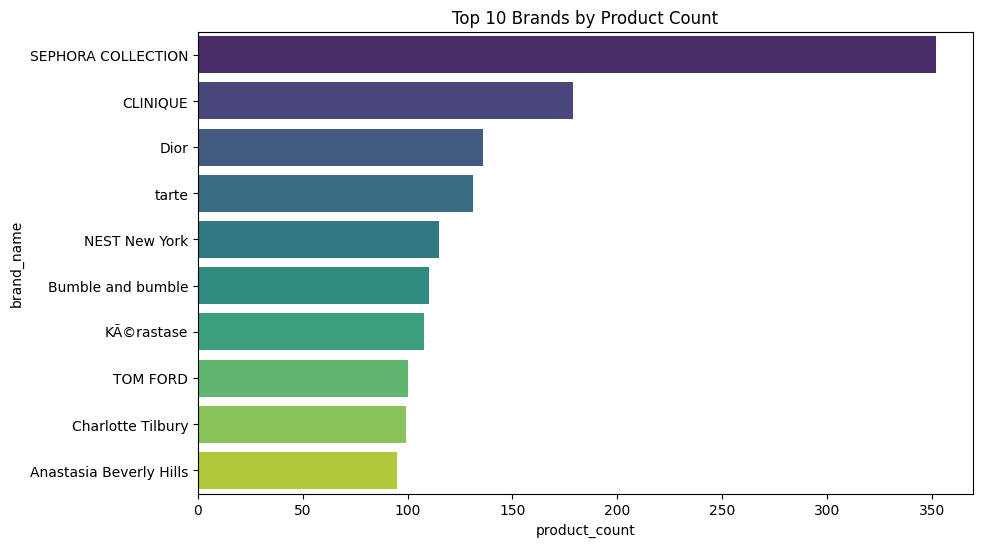

In [22]:
# Number of products for each brand
brand_product_count = product_data.groupby('brand_name')['product_id'].nunique().reset_index()
brand_product_count.columns = ['brand_name', 'product_count']
print("\nNumber of Products per Brand:")
print(brand_product_count)

top_10_brands = brand_product_count.sort_values(by='product_count', ascending=False).head(10)

print("Top 10 Brands by Product Count:")
print(top_10_brands)

# plot top 10 brands
plt.figure(figsize=(10, 6))
sns.barplot(x='product_count', y='brand_name', data=top_10_brands, palette='viridis')
plt.title("Top 10 Brands by Product Count")
plt.show()

Top 10 Most Liked Products:
                                           product_name  \
6242                            Soft Pinch Liquid Blush   
5249                           Radiant Creamy Concealer   
4431  Lip Sleeping Mask Intense Hydration with Vitam...   
6434                    Cream Lip Stain Liquid Lipstick   
2523                 Gloss Bomb Universal Lip Luminizer   
2524  Pro Filtâr Soft Matte Longwear Liquid Founda...   
5250                                              Blush   
247           Brow Wiz Ultra-Slim Precision Brow Pencil   
4458                   Translucent Loose Setting Powder   
7648        Niacinamide 10% + Zinc 1% Oil Control Serum   

                       brand_name  loves_count  
6242  Rare Beauty by Selena Gomez    1401068.0  
5249                         NARS    1153594.0  
4431                      LANEIGE    1081315.0  
6434           SEPHORA COLLECTION    1029051.0  
2523      Fenty Beauty by Rihanna     968317.0  
2524      Fenty Beauty by Ri

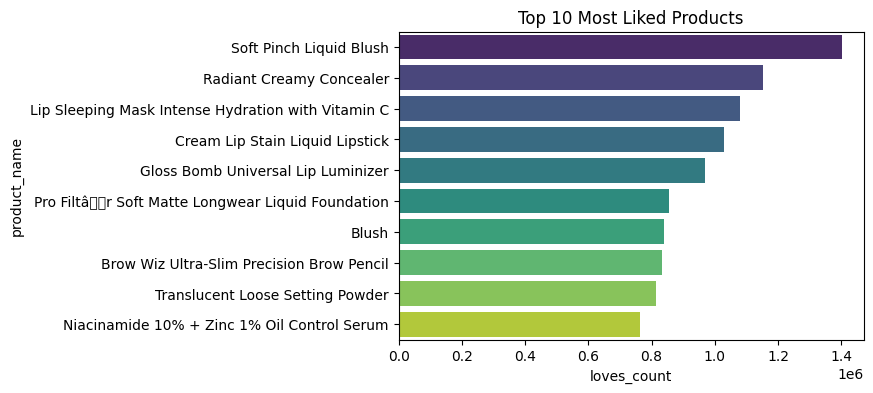

In [118]:
# Top 10 products by loves-count
top_10_liked_products = product_data.sort_values(by='loves_count', ascending=False).head(10)
print("Top 10 Most Liked Products:")
print(top_10_liked_products[['product_name', 'brand_name', 'loves_count']])

# plot top 10 liked products
plt.figure(figsize=(6, 4))
sns.barplot(x='loves_count', y='product_name', data=top_10_liked_products, palette='viridis')
plt.title("Top 10 Most Liked Products")
plt.show()

Top Product of Each Brand for Top 10 Brands:
                                           product_name  \
6434                    Cream Lip Stain Liquid Lipstick   
247           Brow Wiz Ultra-Slim Precision Brow Pencil   
1893                               Dior Addict Lip Glow   
1201                          Hollywood Flawless Filter   
7340                       Amazonian Clay 12-Hour Blush   
7743                   Eye Color Quad Eyeshadow Palette   
1393                                    Almost Lipstick   
851   Hairdresserâs Invisible Oil Heat & UV Protec...   
3980             Elixir Ultime Hydrating Hair Oil Serum   
5384                               Indigo Eau de Parfum   

                   brand_name  loves_count  
6434       SEPHORA COLLECTION    1029051.0  
247   Anastasia Beverly Hills     834189.0  
1893                     Dior     757716.0  
1201        Charlotte Tilbury     496092.0  
7340                    tarte     375001.0  
7743                 TOM FORD     2

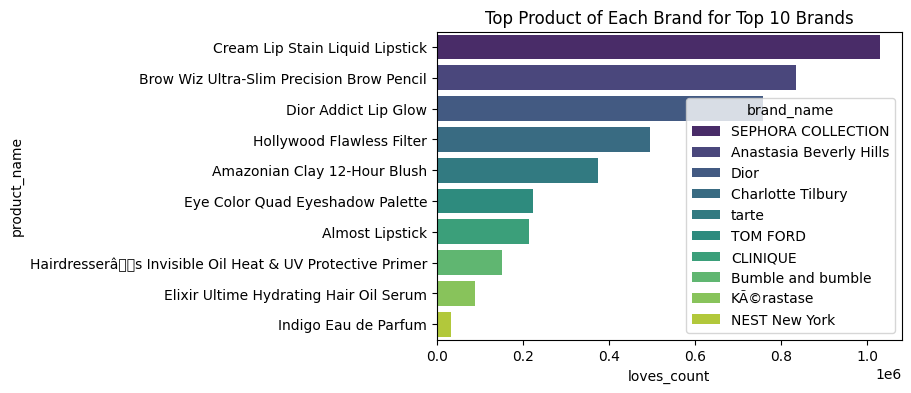

In [119]:
# Top product for each brand by loves-count for the top 10 brands
top_product_per_brand = product_data.sort_values(by='loves_count', ascending=False).groupby('brand_name').head(1)
top_product_per_brand = top_product_per_brand[top_product_per_brand['brand_name'].isin(top_10_brands['brand_name'])]
print("Top Product of Each Brand for Top 10 Brands:")   
print(top_product_per_brand[['product_name', 'brand_name', 'loves_count']])
# plot top product for each brand
plt.figure(figsize=(6, 4))
sns.barplot(x='loves_count', y='product_name', hue='brand_name', data=top_product_per_brand, palette='viridis')
plt.title("Top Product of Each Brand for Top 10 Brands")
plt.show()
# top_2_per_brand = product_data.sort_values(by='loves_count', ascending=False).groupby('brand_name').head(2)
# print("Top 2 Most Liked Products of Each Brand:")
# print(top_2_per_brand[['product_name', 'brand_name', 'loves_count']])

# # plot top 2 products for each brand
# plt.figure(figsize=(10, 6))
# sns.barplot(x='loves_count', y='product_name', hue='brand_name', data=top_2_per_brand, palette='viridis')
# plt.title("Top 2 Most Liked Products of Each Brand")
# plt.show()

Top Product in Each Primary Category:
                                           product_name primary_category  \
6242                            Soft Pinch Liquid Blush           Makeup   
4431  Lip Sleeping Mask Intense Hydration with Vitam...         Skincare   
5569                        No. 3 Hair Repair Perfector             Hair   
7063                       Brazilian Bum Bum Body Cream      Bath & Body   
5251                      Mini Radiant Creamy Concealer        Mini Size   
8430                          Black Opium Eau de Parfum        Fragrance   
6806                                     Eyelash Curler  Tools & Brushes   
4487     Translucent Loose Setting Powder Light Catcher             Face   
3628  Double-Duty Face Moisturizer Broad Spectrum SP...              Men   
3828                                        MMMMâ?7070            Women   
6785                           Happy Birthday Gift Card            Gifts   

       loves_count  
6242  1.401068e+06  
4431  1

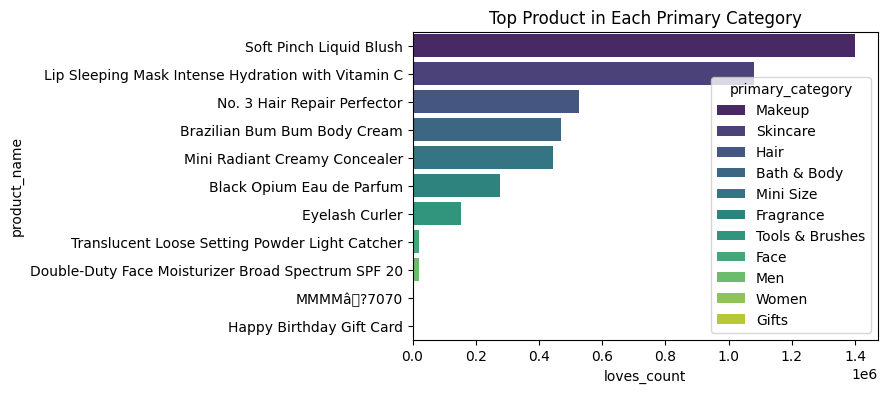

In [120]:
# Top product in each primary category
top_in_primary_category = product_data.sort_values(by='loves_count', ascending=False).groupby('primary_category').head(1)
print("Top Product in Each Primary Category:")
print(top_in_primary_category[['product_name', 'primary_category', 'loves_count']])

# plot top product in each primary category
plt.figure(figsize=(6, 4))
sns.barplot(x='loves_count', y='product_name', hue='primary_category', data=top_in_primary_category, palette='viridis')
plt.title("Top Product in Each Primary Category")
plt.show()


Top Product in Each Top 10 Tertiary Category:
                                           product_name  \
7648        Niacinamide 10% + Zinc 1% Oil Control Serum   
7063                       Brazilian Bum Bum Body Cream   
2228  Protini Polypeptide Firming Refillable Moistur...   
8402                     Superfood Antioxidant Cleanser   
8430                          Black Opium Eau de Parfum   
5571                     No. 4 Bond Maintenance Shampoo   
5573                 No. 5 Bond Maintenance Conditioner   
1569  Dream Coat Supernatural Spray Anti-Frizz Treat...   
3953                          VANILLA | 28 Travel Spray   
8271      Mini Candle Trio - French Cade, Goji & Lychee   

              tertiary_category  loves_count  
7648                Face Serums     763168.0  
7063   Body Lotions & Body Oils     470934.0  
2228               Moisturizers     411372.0  
8402      Face Wash & Cleansers     404142.0  
8430                    Perfume     276396.0  
5571                  

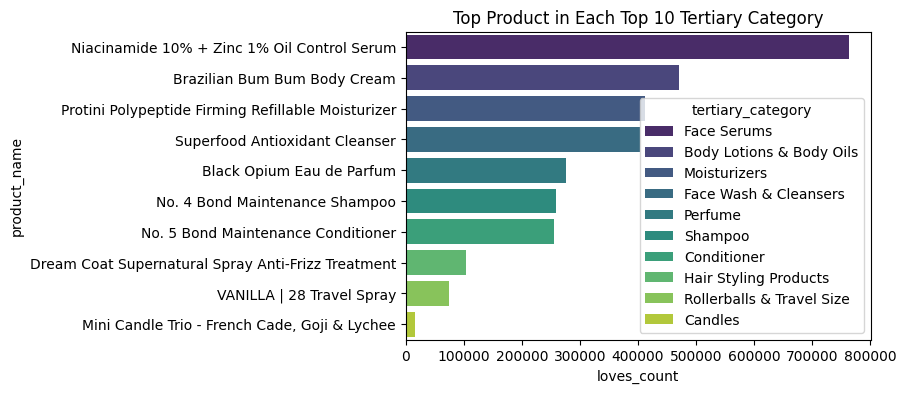

In [121]:
# Top product in top 10 tertiary category
top_in_tertiary_category = product_data.sort_values(by='loves_count', ascending=False).groupby('tertiary_category').head(1)
top_10_tertiary_category = product_data['tertiary_category'].value_counts().head(10).index
top_in_tertiary_category = top_in_tertiary_category[top_in_tertiary_category['tertiary_category'].isin(top_10_tertiary_category)]
print("Top Product in Each Top 10 Tertiary Category:")
print(top_in_tertiary_category[['product_name', 'tertiary_category', 'loves_count']])
# plot top product in top 10 tertiary category
plt.figure(figsize=(6, 4))
sns.barplot(x='loves_count', y='product_name', hue='tertiary_category', data=top_in_tertiary_category, palette='viridis')
plt.title("Top Product in Each Top 10 Tertiary Category")
plt.show()

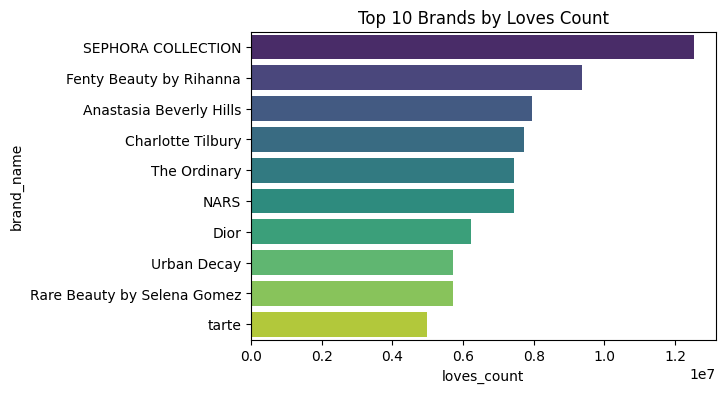

In [122]:
# top 10 brands by loves count
loves_count_per_brand = product_data.groupby('brand_name')['loves_count'].sum().reset_index()
loves_count_per_brand = loves_count_per_brand.sort_values(by='loves_count', ascending=False)

# plot top 10 brands by loves count
plt.figure(figsize=(6, 4))
sns.barplot(x='loves_count', y='brand_name', data=loves_count_per_brand.head(10), palette='viridis')
plt.title("Top 10 Brands by Loves Count")
plt.show()


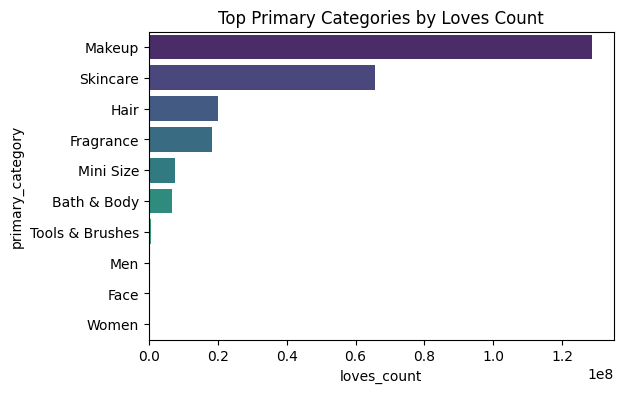

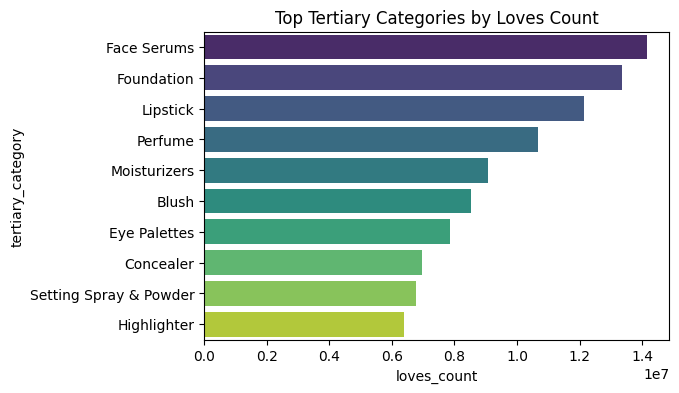

In [123]:
# top primary and tertiary categories by loves count
top_primary_categories = product_data.groupby('primary_category')['loves_count'].sum().reset_index()
top_primary_categories = top_primary_categories.sort_values(by='loves_count', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_primary_categories.head(10), y='primary_category', x='loves_count', palette='viridis')
plt.title('Top Primary Categories by Loves Count')
plt.show()

top_tertiary_categories = product_data.groupby('tertiary_category')['loves_count'].sum().reset_index()
top_tertiary_categories = top_tertiary_categories.sort_values(by='loves_count', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=top_tertiary_categories.head(10), y='tertiary_category', x='loves_count', palette='viridis')
plt.title('Top Tertiary Categories by Loves Count')
plt.show()


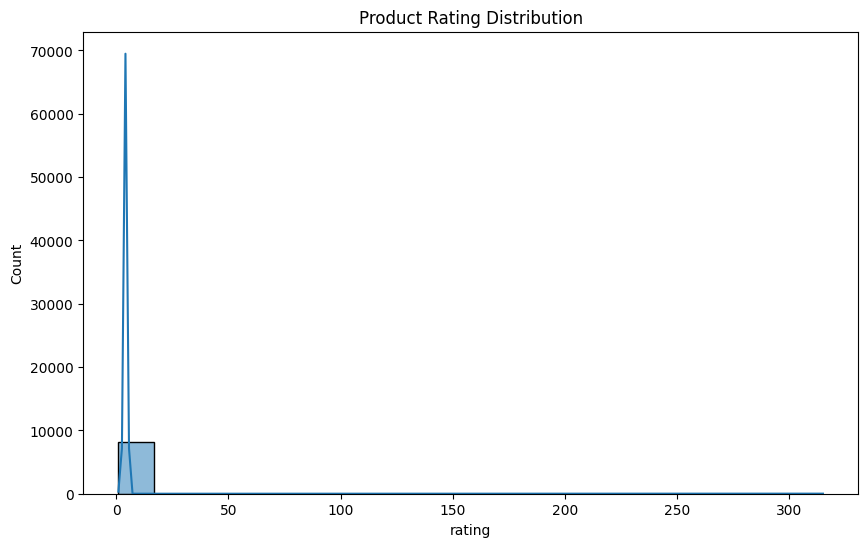

In [33]:
# distribution of product ratings
plt.figure(figsize=(10, 6))
sns.histplot(product_data['rating'], bins=20, kde=True)
plt.title("Product Rating Distribution")
plt.show()

There is outlier in rating

In [36]:
product_data[product_data['rating'] > 50]

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
3828,P412535,MMMMâ?7070,Juliette Has a Gun,13506,4.2127,315.0,3.3 oz/ 100 mL,Size + Concentration + Formulation,3.3 oz/ 100 mL Eau de Parfum Spray,NaN,...,0,0,NaN,Fragrance,Women,Perfume,2,105,30.0,NaN


Removing the above row for analysis of rating column

In [38]:
filtered_data = product_data[product_data['rating'] != 315]

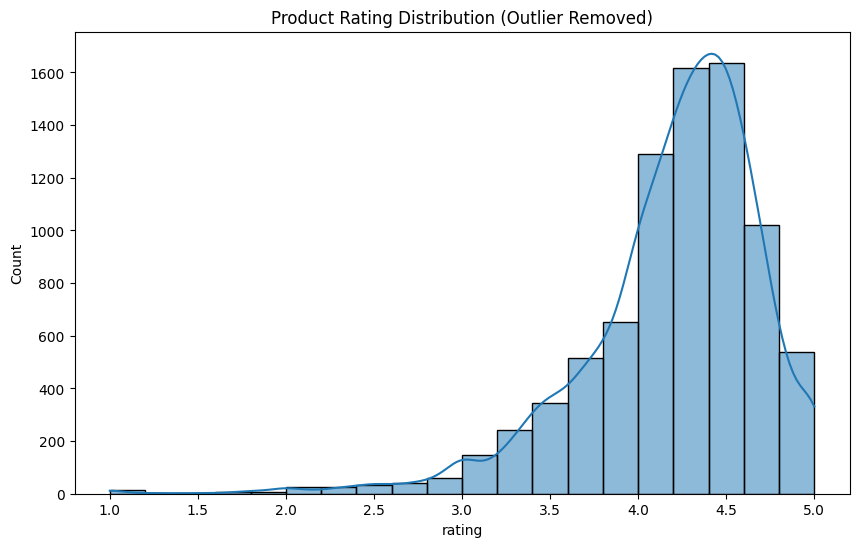

In [40]:
# distribution of product ratings after removing the outlier
plt.figure(figsize=(10, 6))
sns.histplot(filtered_data['rating'], bins=20, kde=True, palette='viridis')
plt.title("Product Rating Distribution (Outlier Removed)")
plt.show()

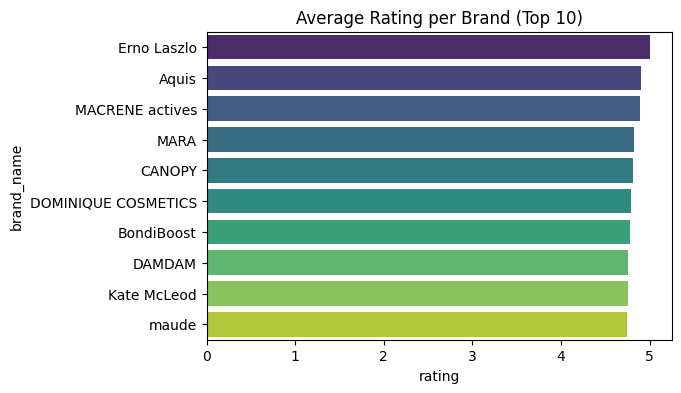

In [124]:
# Average rating per brand (Top 10)
average_rating_per_brand = filtered_data.groupby('brand_name')['rating'].mean().reset_index()
average_rating_per_brand = average_rating_per_brand.sort_values(by='rating', ascending=False)

# plot average rating per brand
plt.figure(figsize=(6, 4))
sns.barplot(x='rating', y='brand_name', data=average_rating_per_brand.head(10), palette='viridis')
plt.title("Average Rating per Brand (Top 10)")
plt.show()

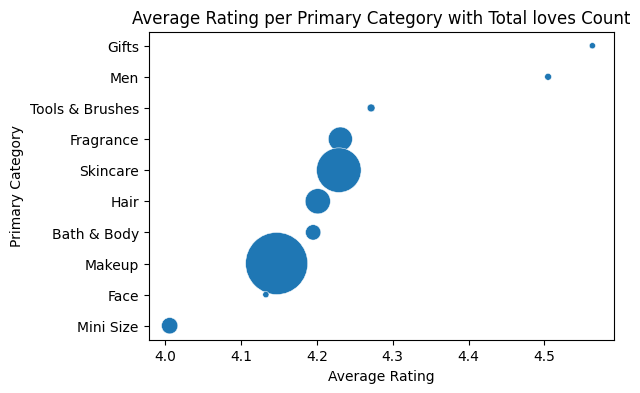

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average rating and product count per primary category
average_rating_per_primary_category = filtered_data.groupby('primary_category').agg(
    average_rating=('rating', 'mean'),
    total_loves_count=('loves_count', 'sum')
).reset_index()

# Sort by average rating
average_rating_per_primary_category = average_rating_per_primary_category.sort_values(by='average_rating', ascending=False)

# Plot bubble chart
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='average_rating', 
    y='primary_category', 
    size='total_loves_count', 
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    data=average_rating_per_primary_category, 
    legend=False, 
    palette='viridis'
)

plt.title("Average Rating per Primary Category with Total loves Count")
plt.xlabel("Average Rating")
plt.ylabel("Primary Category")
plt.show()

In [117]:
# calculate average rating of all the primary categories by category
average_rating_per_primary_category = filtered_data.groupby('primary_category')['rating'].mean().reset_index()
average_rating_per_primary_category = average_rating_per_primary_category.sort_values(by='rating', ascending=False)
average_rating_per_primary_category

,primary_category,rating
3,Gifts,4.563450
6,Men,4.504992
9,Tools & Brushes,4.271458
2,Fragrance,4.230903
8,Skincare,4.228890
4,Hair,4.201113
0,Bath & Body,4.195015
5,Makeup,4.146851
1,Face,4.132600
7,Mini Size,4.005665


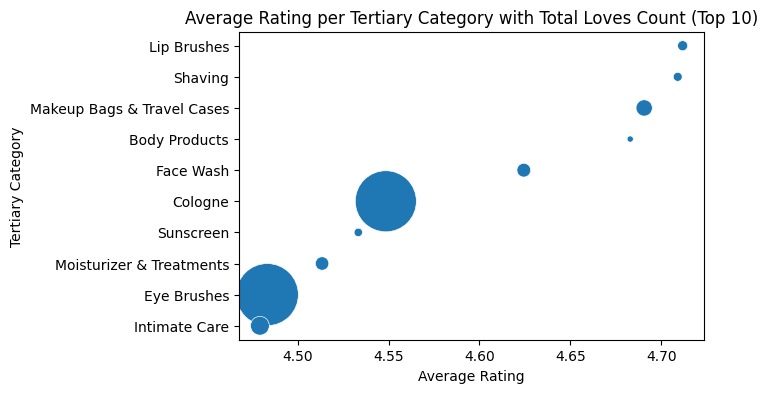

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average rating and sum of loves_count per tertiary category
average_rating_per_tertiary_category = filtered_data.groupby('tertiary_category').agg(
    average_rating=('rating', 'mean'),
    total_loves_count=('loves_count', 'sum')
).reset_index()

# Sort by average rating
average_rating_per_tertiary_category = average_rating_per_tertiary_category.sort_values(by='average_rating', ascending=False)

# Plot bubble chart
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='average_rating', 
    y='tertiary_category', 
    size='total_loves_count', 
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    data=average_rating_per_tertiary_category.head(10),  # Top 10 categories
    legend=False, 
    palette='viridis'
)

plt.title("Average Rating per Tertiary Category with Total Loves Count (Top 10)")
plt.xlabel("Average Rating")
plt.ylabel("Tertiary Category")
plt.show()

price_usd: The price of the product in US dollars

value_price_usd: The potential cost savings of the product, presented on the site next to the regular price

sale_price_usd: The sale price of the product in US dollars

In [48]:
# Check if `value_price_usd` is always greater than or equal to `price_usd`
invalid_rows = product_data[
    product_data['value_price_usd'].notna() &  # Exclude rows where value_price_usd is null
    (product_data['value_price_usd'] < product_data['price_usd'])  # Check if value_price_usd < price_usd
]

# Output the result
if invalid_rows.empty:
    print("The condition 'value_price_usd >= price_usd' is always true (ignoring blanks).")
else:
    print("There are rows where 'value_price_usd < price_usd':")
    print(invalid_rows[['product_name', 'brand_name', 'value_price_usd', 'price_usd','sale_price_usd', 'limited_edition']])


There are rows where 'value_price_usd < price_usd':
                                           product_name         brand_name  \
569        Gimme Brow+ Volumizing  Fiber Eyebrow Pencil  Benefit Cosmetics   
588   Mini Gimme Brow + Volumizing Fiber Eyebrow Pencil  Benefit Cosmetics   
1317                    Makeup Brush Cleaner Travel Set     Cinema Secrets   
2481                   Faceshot Vitamin Ampoules Refill            FaceGym   
5222                    Retinol Youth Renewal Value Duo              Murad   
5433                   Festive Petite Diffuser Trio Set      NEST New York   

      value_price_usd  price_usd  sale_price_usd  limited_edition  
569               0.0       25.0             NaN                0  
588               0.0       15.0             NaN                0  
1317             12.0       15.0             NaN                1  
2481             88.0       90.0             NaN                0  
5222             40.0      126.0             NaN             

There are 6 rows of data where the value price is less than the actual price

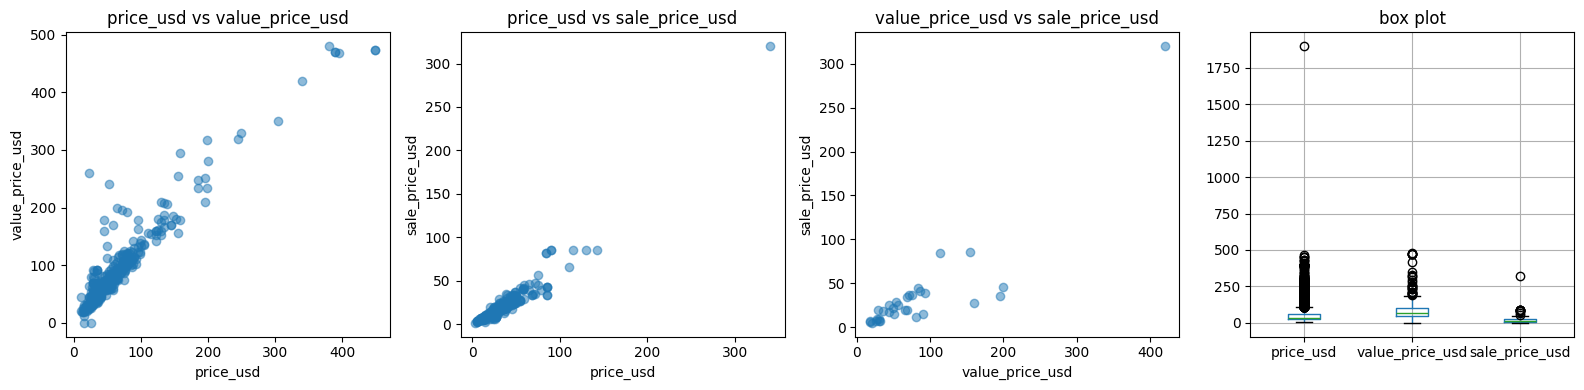

In [141]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.scatter(filtered_data['price_usd'], filtered_data['value_price_usd'], alpha=0.5)
plt.xlabel('price_usd')
plt.ylabel('value_price_usd')
plt.title('price_usd vs value_price_usd')

plt.subplot(1, 4, 2)
plt.scatter(filtered_data['price_usd'], filtered_data['sale_price_usd'], alpha=0.5)
plt.xlabel('price_usd')
plt.ylabel('sale_price_usd')
plt.title('price_usd vs sale_price_usd')

plt.subplot(1, 4, 3)
plt.scatter(filtered_data['value_price_usd'], filtered_data['sale_price_usd'], alpha=0.5)
plt.xlabel('value_price_usd')
plt.ylabel('sale_price_usd')
plt.title('value_price_usd vs sale_price_usd')

plt.subplot(1, 4, 4)
filtered_data[['price_usd', 'value_price_usd', 'sale_price_usd']].boxplot()
plt.title('box plot')

plt.tight_layout()
plt.show()

In [63]:
# Check if `sale_price_usd` is always smaller than or equal to `price_usd`
invalid_rows = filtered_data[
    filtered_data['sale_price_usd'].notna() &  # Exclude rows where sale_price_usd is null
    (filtered_data['sale_price_usd'] > filtered_data['price_usd'])  # Check if sale_price_usd > price_usd
]

# Output the result
if invalid_rows.empty:
    print("The condition 'sale_price_usd <= price_usd' is always true (ignoring blanks).")
else:
    print("There are rows where 'sale_price_usd > price_usd':")
    print(invalid_rows[['product_name', 'brand_name', 'value_price_usd', 'price_usd', 'sale_price_usd', 'limited_edition']])

The condition 'sale_price_usd <= price_usd' is always true (ignoring blanks).


In [78]:
# Calculate perceived savings percentage
product_data['perceived_savings_pct'] = ((product_data['value_price_usd'] - product_data['price_usd']) / product_data['value_price_usd']) * 100

# Calculate actual discount percentage
product_data['discount_pct'] = ((product_data['price_usd'] - product_data['sale_price_usd']) / product_data['price_usd']) * 100

In [79]:
# Check if there are any negative values in `perceived_savings_pct` or `discount_pct`
negative_perceived_savings = product_data[product_data['perceived_savings_pct'] < 0]
negative_discount = product_data[product_data['discount_pct'] < 0]

In [80]:
# display the results
print("Rows with negative perceived savings percentage:")
print(negative_perceived_savings[['product_name', 'brand_name', 'value_price_usd', 'price_usd', 'sale_price_usd', 'perceived_savings_pct']])
print("\nRows with negative discount percentage:")
print(negative_discount[['product_name', 'brand_name', 'value_price_usd', 'price_usd', 'sale_price_usd', 'discount_pct']])

Rows with negative perceived savings percentage:
                                           product_name         brand_name  \
569        Gimme Brow+ Volumizing  Fiber Eyebrow Pencil  Benefit Cosmetics   
588   Mini Gimme Brow + Volumizing Fiber Eyebrow Pencil  Benefit Cosmetics   
1317                    Makeup Brush Cleaner Travel Set     Cinema Secrets   
2481                   Faceshot Vitamin Ampoules Refill            FaceGym   
5222                    Retinol Youth Renewal Value Duo              Murad   
5433                   Festive Petite Diffuser Trio Set      NEST New York   

      value_price_usd  price_usd  sale_price_usd  perceived_savings_pct  
569               0.0       25.0             NaN                   -inf  
588               0.0       15.0             NaN                   -inf  
1317             12.0       15.0             NaN             -25.000000  
2481             88.0       90.0             NaN              -2.272727  
5222             40.0      126.0  

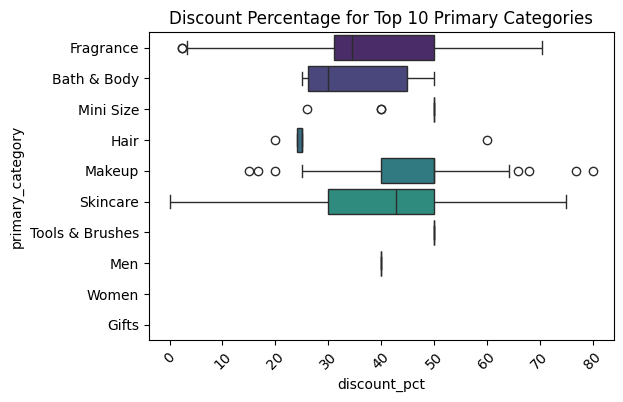

In [142]:
# boxplot the discount percentage for the top 10 primary categories
top_10_primary_categories = product_data['primary_category'].value_counts().head(10).index
discount_pct_top_10_primary_categories = product_data[product_data['primary_category'].isin(top_10_primary_categories)]

plt.figure(figsize=(6, 4))
sns.boxplot(y='primary_category', x='discount_pct', data=discount_pct_top_10_primary_categories, palette='viridis')
plt.title("Discount Percentage for Top 10 Primary Categories")
plt.xticks(rotation=45)
plt.show()

In [66]:
# Calculate percentage discount for each product
product_data['discount_pct'] = ((product_data['price_usd'] - product_data['sale_price_usd']) / product_data['price_usd']) * 100

# Handle cases where sale_price_usd is missing or zero to avoid division errors
product_data['discount_pct'] = product_data['discount_pct'].fillna(0).clip(lower=0)

# Sort products by discount percentage in descending order
sorted_discounts = product_data.sort_values(by='discount_pct', ascending=False)

# Select relevant columns for output
discounted_products = sorted_discounts[['product_name', 'brand_name', 'price_usd', 'sale_price_usd', 'discount_pct', 'limited_edition']]

# Display the top 10 products with the highest discount percentage
print(discounted_products.head(10))


                                      product_name          brand_name  \
6478               Cream Lip Shine Liquid Lipstick  SEPHORA COLLECTION   
499          BOUNCE Airbrush Liquid Whip Concealer       beautyblender   
6757           Double-Ended Textured Facial Roller  SEPHORA COLLECTION   
7736                               Maya Rollerball               TOCCA   
7735                                          Maya               TOCCA   
7732                          Giulietta Rollerball               TOCCA   
7730                                           Gia               TOCCA   
7739                                Gia Rollerball               TOCCA   
6471  Make No Mistake Foundation & Concealer Stick  SEPHORA COLLECTION   
6721                    Wishing You Eye Makeup Set  SEPHORA COLLECTION   

      price_usd  sale_price_usd  discount_pct  limited_edition  
6478       15.0             3.0     80.000000                0  
499        26.0             6.0     76.923077          

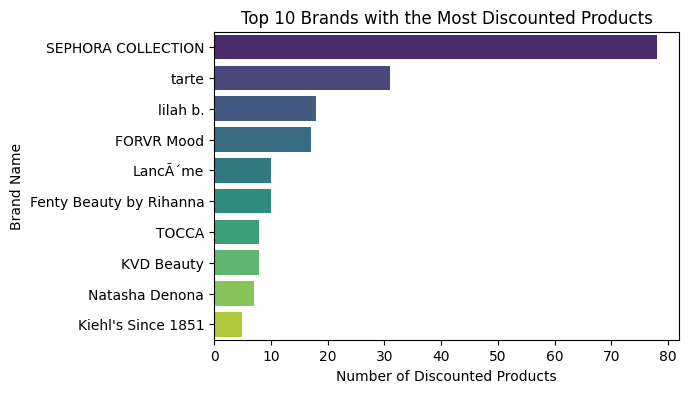

In [143]:
# Filter for products with a significant discount (e.g., greater than 0%)
discounted_products_filtered = discounted_products[discounted_products['discount_pct'] > 0]

# Count the number of discounted products per brand
brand_discount_counts = discounted_products_filtered['brand_name'].value_counts().reset_index()
brand_discount_counts.columns = ['brand_name', 'count']

# Plot the top 10 brands with the most discounted products
plt.figure(figsize=(6, 4))
sns.barplot(x='count', y='brand_name', data=brand_discount_counts.head(10), palette='viridis')
plt.title('Top 10 Brands with the Most Discounted Products')
plt.xlabel('Number of Discounted Products')
plt.ylabel('Brand Name')
plt.show()

In [90]:
# Filter for discounted products with a significant discount (e.g., >0%)
discounted_products_filtered = discounted_products[discounted_products['discount_pct'] > 0]

# Further filter for limited edition products
limited_edition_discounted = discounted_products_filtered[discounted_products_filtered['limited_edition'] == True]

# Select relevant columns for output
limited_edition_discounted_products = limited_edition_discounted[['product_name', 'brand_name', 'price_usd', 'sale_price_usd', 'discount_pct', 'limited_edition']]

# Display the products that are discounted and also limited edition
print(limited_edition_discounted_products)

# Optional: Count of such products
count_limited_edition_discounted = limited_edition_discounted_products.shape[0]
print(f"Number of discounted limited edition products: {count_limited_edition_discounted}")

                                           product_name           brand_name  \
6721                         Wishing You Eye Makeup Set   SEPHORA COLLECTION   
4278  Kitten Mini: Purrfect Cat Eyes Mini Mascara & ...           KVD Beauty   
6655               Wishing You 12 Pan Eyeshadow Palette   SEPHORA COLLECTION   
6642                    Winter Wonderland Eye Brush Set   SEPHORA COLLECTION   
6719                                 Lip Gloss Ornament   SEPHORA COLLECTION   
...                                                 ...                  ...   
1047                  Party Wave Mascara & Eyeliner Set              caliray   
3744                         Christmas Cracker Gift Set     Jo Malone London   
3727                                Mini Essentials Set     Jo Malone London   
8424  The Youth Vault: 13-Piece Vegan Skincare + App...  Youth To The People   
6989                                  Fall Cashmere Set               SKYLAR   

      price_usd  sale_price_usd  discou

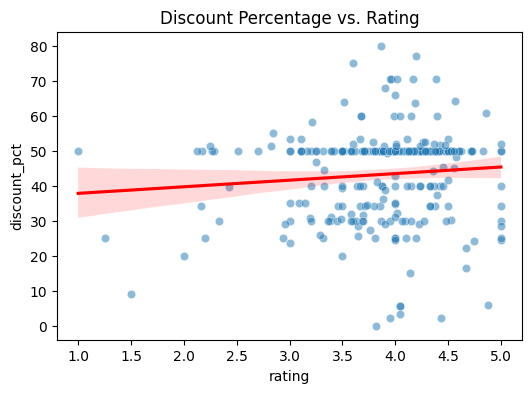

In [144]:
# Is there any relationship between discount and rating?
filtered_data = product_data[product_data['rating'] <50]
plt.figure(figsize=(6, 4))
sns.scatterplot(data=filtered_data, x='rating', y='discount_pct', alpha=0.5, palette='viridis')
plt.title('Discount Percentage vs. Rating')
plt.xlabel('Rating')
plt.ylabel('Discount Percentage (%)')
sns.regplot(data=filtered_data, x='rating', y='discount_pct', scatter=False, color='red')
plt.show()

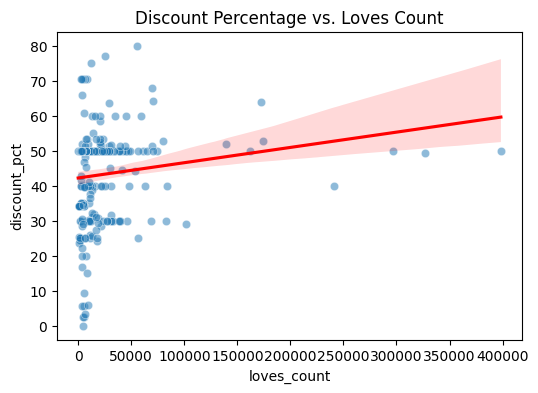

In [145]:
# Is there any relationship between discount and loves count?
plt.figure(figsize=(6, 4))
sns.scatterplot(data=filtered_data, x='loves_count', y='discount_pct', alpha=0.5, palette='viridis')
plt.title('Discount Percentage vs. Loves Count')
plt.xlabel('Loves Count')
plt.ylabel('Discount Percentage (%)')
sns.regplot(data=filtered_data, x='loves_count', y='discount_pct', scatter=False, color='red')
plt.show()